<a href="https://colab.research.google.com/github/swayambel/orbital-integrator-stability-checker/blob/main/orbital_integrators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symplectic vs Non-Symplectic Integrators for Orbital Motion

---

**Author:** Swayam Beluse
**Topic:** Numerical Integration of the Two-Body Gravitational Problem  
**Tools:** Python · NumPy · Matplotlib

---


## 1. Overview

This notebook presents a comparative study of four classical numerical integrators applied to the two-body gravitational problem. Two of the integrators — **Velocity Verlet** and **Leapfrog** — are *symplectic*, meaning they are designed to preserve the geometric (Hamiltonian) structure of the equations of motion. The other two — **RK4** and **Heun's method**.
The central question explored here is:

> **Do symplectic integrators conserve energy and maintain orbital stability better than non-symplectic ones over long integration times?**

This is a foundational question in computational celestial mechanics, molecular dynamics, and any field where long-time Hamiltonian dynamics must be simulated faithfully.

## 2. Project Objectives

The objectives of this study are:

1. Implement four numerical integrators: **RK4**, **Heun**, **Velocity Verlet**, and **Leapfrog**.
2. Simulate a circular orbit using normalized gravitational units ($GM = 1$).
3. Compare **energy conservation** over 15,000 timesteps.
4. Analyze **orbital radius drift** as a proxy for trajectory stability.
5. Inspect **phase-space structure** to understand geometric preservation.
6. Perform a **timestep sensitivity analysis** to characterize how each integrator degrades with larger $\Delta t$.

## 3. Physical Model

We study the classical **two-body gravitational problem**, reduced to the motion of a test particle in the gravitational field of a fixed central mass. This is one of the simplest non-trivial dynamical systems, yet it is a canonical benchmark for numerical integrators.

The system is a **Hamiltonian system** with the following energy:

$$H = \frac{1}{2}(v_x^2 + v_y^2) - \frac{GM}{|\mathbf{r}|}$$

where $\mathbf{r} = (x, y)$ is the position vector and $\mathbf{v} = (v_x, v_y)$ is the velocity. The total energy $H$ is a **conserved quantity** of the exact dynamics. Any numerical drift in $H$ over time is an artifact of the integrator, not the physics.

Symplectic integrators are constructed to preserve a *modified* Hamiltonian that is close to the true one, resulting in **bounded energy oscillations** rather than secular (monotonic) drift. Non-symplectic integrators have no such guarantee.

## 4. Equations of Motion

The equations of motion in Cartesian coordinates are:

$$\frac{d^2 \mathbf{r}}{dt^2} = -\frac{GM\, \mathbf{r}}{|\mathbf{r}|^3}$$

Decomposed into components:

$$\ddot{x} = -\frac{GM\, x}{(x^2 + y^2)^{3/2}}, \qquad \ddot{y} = -\frac{GM\, y}{(x^2 + y^2)^{3/2}}$$

We use normalized units with $GM = 1$, so the equations simplify to:

$$\ddot{\mathbf{r}} = -\frac{\mathbf{r}}{|\mathbf{r}|^3}$$

The specific orbital energy (energy per unit mass) is:

$$E = \frac{1}{2}|\mathbf{v}|^2 - \frac{1}{|\mathbf{r}|}$$

For a circular orbit at $r = 1$ with $v = 1$, the exact energy is $E_0 = -0.5$.

## 5. Initial Conditions

We initialize the orbit with:

| Quantity | Value |
|----------|-------|
| $x_0$ | $1.0$ |
| $y_0$ | $0.0$ |
| $v_{x,0}$ | $0.0$ |
| $v_{y,0}$ | $1.0$ |
| $GM$ | $1.0$ |
| $\Delta t$ | $0.05$ |
| Steps | $15000$ |

These initial conditions satisfy the circular orbit condition $v = \sqrt{GM/r} = 1$, giving an orbital period of $T = 2\pi \approx 6.28$ time units. The simulation covers approximately **1194 orbital periods**, making energy conservation a stringent test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator

plt.style.use("seaborn-v0_8-darkgrid")

COLORS = {
    "RK4":            "#E07B54",
    "Heun":           "#C94040",
    "Velocity Verlet":"#4A90D9",
    "Leapfrog":       "#2ECC71",
}

GM   = 1.0
x0   = 1.0
y0   = 0.0
vx0  = 0.0
vy0  = 1.0
dt   = 0.05
steps = 15000

print(f"Orbital period T = {2*np.pi:.4f}")
print(f"Total time      = {dt*steps:.1f}")
print(f"Orbital periods = {dt*steps/(2*np.pi):.1f}")
print(f"Exact energy E0 = {0.5*vy0**2 - GM/x0:.4f}")

Orbital period T = 6.2832
Total time      = 750.0
Orbital periods = 119.4
Exact energy E0 = -0.5000


## 6. Description of Numerical Integrators

### 6.1 Heun's Method (RK2 Predictor-Corrector)
Heun's method is a second-order Runge-Kutta scheme. It first takes a full Euler step to predict the state at $t + \Delta t$, then averages the slopes at the beginning and end of the interval. It is **non-symplectic** and known to exhibit **energy growth** in conservative systems — the orbit will spiral outward over time.

### 6.2 Runge-Kutta 4 (RK4)
RK4 is the workhorse of scientific computing — a fourth-order, non-symplectic method. It evaluates the derivative at four intermediate points per step, achieving excellent short-time accuracy. However, it is **not symplectic**, so it does not preserve the Hamiltonian structure. Over long integrations it will exhibit slow but nonzero energy drift.

### 6.3 Velocity Verlet
Velocity Verlet is a second-order **symplectic** integrator derived from the Störmer-Verlet splitting. It updates positions using current velocities and accelerations, then updates velocities using a half-step average. It preserves the symplectic 2-form, guaranteeing **bounded energy oscillations** — no secular drift.

### 6.4 Leapfrog (Kick-Drift-Kick)
The Leapfrog integrator is also a second-order symplectic method. It staggers position and velocity updates by half a timestep: positions and velocities are never synchronized, but this "out-of-phase" update is exactly what preserves the symplectic structure. Like Velocity Verlet, it shows **no secular energy drift** and is the method of choice in long-duration simulations.

## 7. Implementation of Integrators

In [2]:
def acceleration(x, y):
    r3 = (x**2 + y**2)**1.5
    return -GM * x / r3, -GM * y / r3

def specific_energy(x, y, vx, vy):
    r = np.sqrt(x**2 + y**2)
    return 0.5 * (vx**2 + vy**2) - GM / r

def radius(x, y):
    return np.sqrt(x**2 + y**2)

def angular_momentum(x, y, vx, vy):
    return x*vy - y*vx

def step_heun(x, y, vx, vy, dt):
    ax0, ay0 = acceleration(x, y)
    xp  = x  + vx  * dt
    yp  = y  + vy  * dt
    vxp = vx + ax0 * dt
    vyp = vy + ay0 * dt
    ax1, ay1 = acceleration(xp, yp)
    x_new  = x  + 0.5 * (vx  + vxp) * dt
    y_new  = y  + 0.5 * (vy  + vyp) * dt
    vx_new = vx + 0.5 * (ax0 + ax1) * dt
    vy_new = vy + 0.5 * (ay0 + ay1) * dt
    return x_new, y_new, vx_new, vy_new


def step_rk4(x, y, vx, vy, dt):
    def deriv(x, y, vx, vy):
        ax, ay = acceleration(x, y)
        return vx, vy, ax, ay

    k1 = deriv(x, y, vx, vy)
    k2 = deriv(x + 0.5*dt*k1[0], y + 0.5*dt*k1[1],
               vx + 0.5*dt*k1[2], vy + 0.5*dt*k1[3])
    k3 = deriv(x + 0.5*dt*k2[0], y + 0.5*dt*k2[1],
               vx + 0.5*dt*k2[2], vy + 0.5*dt*k2[3])
    k4 = deriv(x + dt*k3[0], y + dt*k3[1],
               vx + dt*k3[2], vy + dt*k3[3])

    c = dt / 6.0
    x_new  = x  + c*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    y_new  = y  + c*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    vx_new = vx + c*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    vy_new = vy + c*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    return x_new, y_new, vx_new, vy_new


def step_velocity_verlet(x, y, vx, vy, dt):
    ax0, ay0 = acceleration(x, y)
    x_new  = x  + vx  * dt + 0.5 * ax0 * dt**2
    y_new  = y  + vy  * dt + 0.5 * ay0 * dt**2
    ax1, ay1 = acceleration(x_new, y_new)
    vx_new = vx + 0.5 * (ax0 + ax1) * dt
    vy_new = vy + 0.5 * (ay0 + ay1) * dt
    return x_new, y_new, vx_new, vy_new


def step_leapfrog(x, y, vx_half, vy_half, dt):
    x_new  = x + vx_half * dt
    y_new  = y + vy_half * dt
    ax, ay = acceleration(x_new, y_new)
    vx_new = vx_half + ax * dt
    vy_new = vy_half + ay * dt
    return x_new, y_new, vx_new, vy_new

## 8. Orbit Simulation

We now run all four integrators for 15,000 steps with $\Delta t = 0.05$. For the Leapfrog integrator, we initialize the half-step velocity using a single Euler kick backward by $\Delta t / 2$, which is the standard initialization for staggered schemes.

In [3]:
def run_integrator(integrator_name, steps=steps, dt=dt):
    xs  = np.zeros(steps + 1)
    ys  = np.zeros(steps + 1)
    vxs = np.zeros(steps + 1)
    vys = np.zeros(steps + 1)

    xs[0], ys[0], vxs[0], vys[0] = x0, y0, vx0, vy0

    if integrator_name == "Leapfrog":
        ax0, ay0 = acceleration(x0, y0)
        vx_h = vx0 - 0.5 * dt * ax0
        vy_h = vy0 - 0.5 * dt * ay0
        for i in range(steps):
            xs[i+1], ys[i+1], vx_h, vy_h = step_leapfrog(xs[i], ys[i], vx_h, vy_h, dt)
            ax, ay = acceleration(xs[i+1], ys[i+1])
            vxs[i+1] = vx_h - 0.5 * dt * ax
            vys[i+1] = vy_h - 0.5 * dt * ay
    else:
        step_fn = {"RK4": step_rk4, "Heun": step_heun, "Velocity Verlet": step_velocity_verlet}[integrator_name]
        for i in range(steps):
            xs[i+1], ys[i+1], vxs[i+1], vys[i+1] = step_fn(xs[i], ys[i], vxs[i], vys[i], dt)

    return xs, ys, vxs, vys


results = {}
for name in ["RK4", "Heun", "Velocity Verlet", "Leapfrog"]:
    xs, ys, vxs, vys = run_integrator(name)
    E = specific_energy(xs, ys, vxs, vys)
    R = radius(xs, ys)
    L = angular_momentum(xs, ys, vxs, vys)
    results[name] = {"x": xs, "y": ys, "vx": vxs, "vy": vys, "E": E, "R": R, "L": L}
    print(f"{name:<20} | E_final = {E[-1]:.6f} | R_final = {R[-1]:.6f}")

E0   = specific_energy(x0, y0, vx0, vy0)
time = np.linspace(0, dt * steps, steps + 1)
print(f"\nExact energy E0 = {E0:.6f}")

RK4                  | E_final = -0.500003 | R_final = 0.999993
Heun                 | E_final = -0.480005 | R_final = 1.045542
Velocity Verlet      | E_final = -0.499999 | R_final = 1.000964
Leapfrog             | E_final = -0.498772 | R_final = 0.969349

Exact energy E0 = -0.500000


### Plot 1 — Orbit Trajectories

The first diagnostic is the simplest: where does the orbit go? A perfect circular orbit should retrace the unit circle indefinitely.

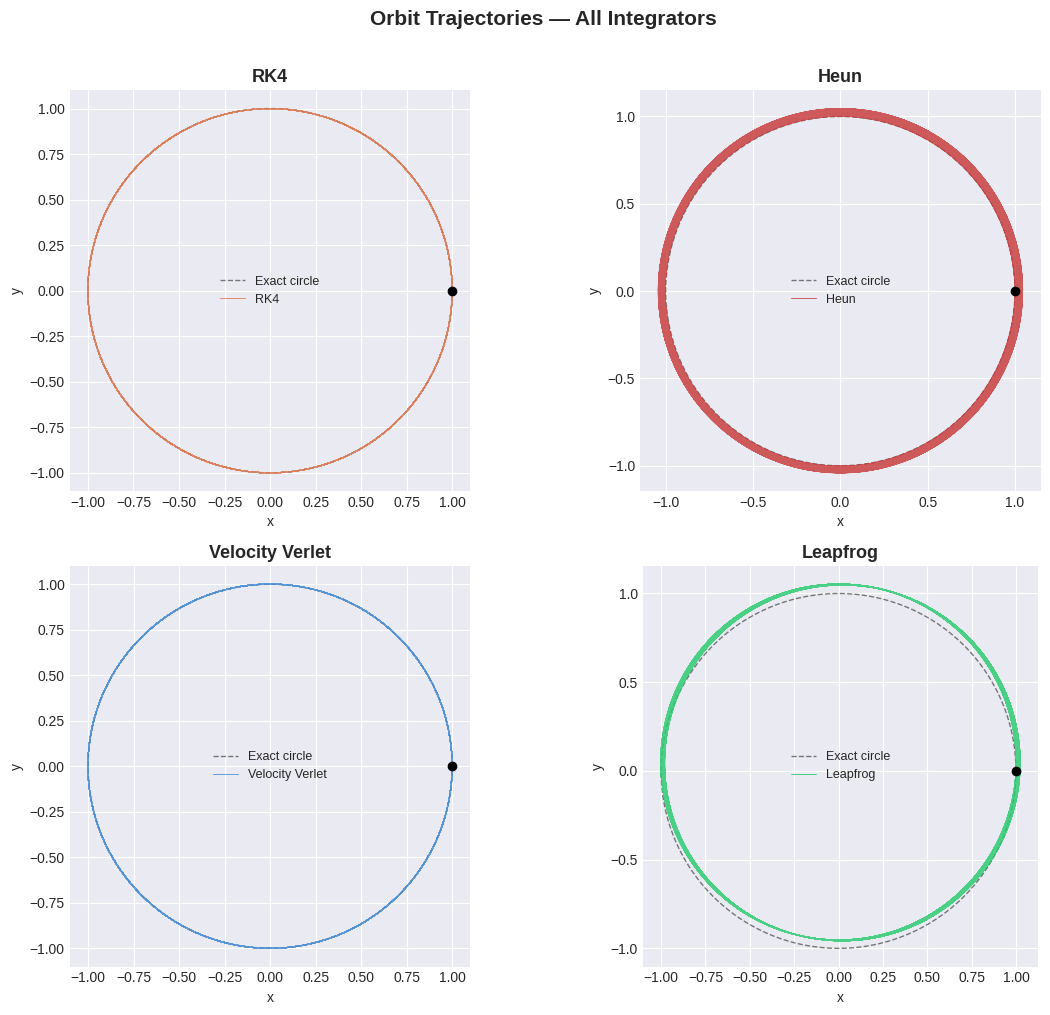

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
theta_ref = np.linspace(0, 2*np.pi, 500)

for ax, (name, data) in zip(axes, results.items()):
    ax.plot(np.cos(theta_ref), np.sin(theta_ref), 'k--', lw=1, alpha=0.5, label='Exact circle')
    ax.plot(data["x"], data["y"], color=COLORS[name], lw=0.7, alpha=0.85, label=name)
    ax.plot(x0, y0, 'ko', ms=6, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)

fig.suptitle('Orbit Trajectories — All Integrators', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('orbit_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The Heun integrator exhibits a clearly visible outward spiral — the orbit gains energy over time, causing the radius to grow. The RK4 trajectory maintains a visually circular orbit for much longer, but subtle drift may accumulate. The Velocity Verlet and Leapfrog orbits trace a near-perfect circle throughout the simulation, with only imperceptible geometric drift. This immediate visual comparison already hints at the fundamental difference in long-time behavior.

## Numerical Integrators

Four numerical integrators are tested.

### RK4

Fourth-order Runge-Kutta integrator that evaluates the derivative four times per timestep. It is widely used due to its high local accuracy.

### Heun Method

A second-order predictor-corrector method that averages the derivative at the beginning and end of the timestep.

### Velocity Verlet

A symplectic integrator commonly used in molecular dynamics and orbital mechanics. It preserves phase-space structure and exhibits good long-term stability.

### Leapfrog

Another symplectic method that staggers position and velocity updates, ensuring time-reversibility and improved conservation properties.

## 3. Runge–Kutta 4 (RK4)

The Runge–Kutta 4 method is a fourth-order numerical integrator widely used for solving ordinary differential equations.

It improves accuracy by evaluating the derivative at four intermediate points within each timestep and combining them in a weighted average.

Although RK4 has very small local truncation error, it is **not a symplectic method**. As a result, long-term simulations of Hamiltonian systems may exhibit gradual energy drift.

In [ ]:
def rk4_step(state, dt):

    k1 = derivatives(state)
    k2 = derivatives(state + 0.5 * dt * k1)
    k3 = derivatives(state + 0.5 * dt * k2)
    k4 = derivatives(state + dt * k3)

    return state + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

### Simulation Parameters

In [ ]:
dt = 0.15
steps = 50000

### RK4 Simluation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_rk4 = []

for _ in range(steps):
    trajectory_rk4.append(state[:2])
    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(trajectory_rk4[0,0],trajectory_rk4[0,1],
            color="green",label="Start")

plt.scatter(trajectory_rk4[-1,0],trajectory_rk4[-1,1],
            color="red",label="End")

plt.plot(
    trajectory_rk4[:,0],
    trajectory_rk4[:,1],
    color="gold",
    label="RK4 Orbit"
)


plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using RK4 Integrator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The RK4 integrator produces a nearly perfect circular orbit for the chosen timestep. The start and end points of the trajectory remain extremely close, indicating very small short-term numerical error. RK4 achieves high accuracy by evaluating derivatives multiple times within each timestep.
This reduces local truncation error and allows the method to closely approximate the true trajectory over short time intervals.However, RK4 is not a symplectic integrator. While it minimizes local error, it does not preserve the Hamiltonian structure of the system. As a result, very long simulations may still exhibit gradual drift in conserved quantities such as total energy.

## 4. Heun Integrator (Improved Euler)

The Heun method is a second-order predictor–corrector integrator that improves upon the basic Euler method.

The method first predicts the next state using a simple Euler step and then corrects this estimate by averaging the derivative at the beginning and end of the timestep.

Although more accurate than Euler, Heun is still a **non-symplectic integrator**. Therefore, small numerical errors may accumulate over long simulations of Hamiltonian systems such as orbital motion.

In [ ]:
def heun_step(state, dt):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)
    ax = -x/r**3
    ay = -y/r**3

    k1 = np.array([vx, vy, ax, ay])
    predictor = state + dt*k1

    x2, y2, vx2, vy2 = predictor
    r2 = np.sqrt(x2**2 + y2**2)
    ax2 = -x2/r2**3
    ay2 = -y2/r2**3

    k2 = np.array([vx2, vy2, ax2, ay2])

    return state + dt*(k1 + k2)/2

### Heun Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_heun = []

for _ in range(steps):
    trajectory_heun.append(state[:2])
    state = heun_step(state, dt)

trajectory_heun = np.array(trajectory_heun)

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_heun[:,0],
    trajectory_heun[:,1],
    color="magenta",
    label="Heun Orbit"
)

plt.scatter(
    trajectory_heun[0,0],
    trajectory_heun[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_heun[-1,0],
    trajectory_heun[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Heun Integrator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The Heun integrator produces an orbit that remains approximately circular for the duration of the simulation. Compared with the Euler method, the trajectory is significantly more stable because the Heun method averages the derivative at two points within the timestep. However, a small deviation between the start and end points is still visible, indicating the presence of numerical error accumulation over time. Although the method improves accuracy relative to first-order schemes, it does not preserve the Hamiltonian structure of the gravitational system, meaning long-term simulations may still exhibit energy drift.

## 5. Velocity Verlet Integrator

The Velocity Verlet method is a second-order symplectic integrator commonly used in molecular dynamics and orbital simulations.

Unlike standard Runge–Kutta methods, symplectic integrators preserve the geometric structure of Hamiltonian systems. This property helps maintain long-term stability in simulations of conservative systems such as gravitational motion.

The Velocity Verlet algorithm updates position and velocity using both the current and updated accelerations, allowing the method to maintain bounded energy oscillations over long simulations.

### Acceleration Function

In [ ]:
def acceleration(x, y):

    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return ax, ay

### Velocity Verlet Step Function

In [ ]:
def velocity_verlet_step(state, dt):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)
    ax = -x/r**3
    ay = -y/r**3

    x_new = x + vx*dt + 0.5*ax*dt**2
    y_new = y + vy*dt + 0.5*ay*dt**2

    r_new = np.sqrt(x_new**2 + y_new**2)

    ax_new = -x_new/r_new**3
    ay_new = -y_new/r_new**3
    vx_new = vx + 0.5*(ax + ax_new)*dt
    vy_new = vy + 0.5*(ay + ay_new)*dt

    return np.array([x_new, y_new, vx_new, vy_new])

### Velocity Verlet Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_verlet = []

for _ in range(steps):
    trajectory_verlet.append(state[:2])
    state = velocity_verlet_step(state, dt)

trajectory_verlet = np.array(trajectory_verlet)

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_verlet[:,0],
    trajectory_verlet[:,1],
    color="cyan",
    label="Velocity Verlet Orbit"
)

plt.scatter(
    trajectory_verlet[0,0],
    trajectory_verlet[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_verlet[-1,0],
    trajectory_verlet[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Velocity Verlet Integrator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The Velocity Verlet integrator produces a highly stable circular orbit for the gravitational system. Unlike standard Runge–Kutta methods, Velocity Verlet is a symplectic integrator, meaning it preserves the Hamiltonian structure of the system. This property allows the integrator to maintain long-term stability even when the timestep is relatively large. In orbital simulations, symplectic methods typically produce bounded oscillations in conserved quantities such as energy rather than the gradual drift seen in non-symplectic methods.

## 6. Leapfrog Integrator

The Leapfrog method is a symplectic integrator commonly used in simulations of gravitational and Hamiltonian systems.

In this method, position and velocity are updated at staggered time intervals. Velocity is first updated by half a timestep, after which position is updated using this intermediate velocity.

Because Leapfrog preserves the Hamiltonian structure of the system, it maintains long-term stability in orbital simulations and prevents artificial energy drift.

In [ ]:
def leapfrog_step(state, dt):

    x, y, vx, vy = state

    ax, ay = acceleration(x, y)

    # half-step velocity
    vx_half = vx + 0.5 * ax * dt
    vy_half = vy + 0.5 * ay * dt

    # position update
    x_new = x + vx_half * dt
    y_new = y + vy_half * dt

    # acceleration at new position
    ax_new, ay_new = acceleration(x_new, y_new)

    # complete velocity update
    vx_new = vx_half + 0.5 * ax_new * dt
    vy_new = vy_half + 0.5 * ay_new * dt

    return np.array([x_new, y_new, vx_new, vy_new])

### Leapfrog Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_leapfrog = []

for _ in range(steps):
    trajectory_leapfrog.append(state[:2])
    state = leapfrog_step(state, dt)

trajectory_leapfrog = np.array(trajectory_leapfrog)

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_leapfrog[:,0],
    trajectory_leapfrog[:,1],
    color="orange",
    label="Leapfrog Orbit"
)

plt.scatter(
    trajectory_leapfrog[0,0],
    trajectory_leapfrog[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_leapfrog[-1,0],
    trajectory_leapfrog[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Leapfrog Integrator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The Leapfrog integrator produces a stable circular orbit similar to the Velocity Verlet method. Because Leapfrog is a symplectic integrator, it preserves the Hamiltonian structure of the gravitational system and maintains long-term stability in orbital simulations. The orbit remains nearly circular throughout the simulation, and the small displacement between the start and end points reflects only minor phase error accumulated over multiple orbital periods.

## 7. Orbit Comparison

After implementing the four numerical integrators, their orbital trajectories can now be compared directly.

The goal of this comparison is to visually inspect how each integrator reproduces the circular orbit under identical timestep and initial conditions.

Although the orbit plots may appear similar for sufficiently small timesteps, subtle numerical differences still exist. These differences become more visible when analyzing conserved quantities such as total energy and orbital radius over long simulations.

In [ ]:
plt.figure(figsize=(7,7))

skip = 10   # downsample for cleaner orbit

plt.plot(traj_rk4[::skip,0], traj_rk4[::skip,1],
         label="RK4", linewidth=1.5)

plt.plot(traj_heun[::skip,0], traj_heun[::skip,1],
         label="Heun", linewidth=1.5)

plt.plot(traj_verlet[::skip,0], traj_verlet[::skip,1],
         label="Velocity Verlet", linewidth=1.5)

plt.plot(traj_leapfrog[::skip,0], traj_leapfrog[::skip,1],
         label="Leapfrog", linewidth=1.5)

plt.scatter(traj_rk4[0,0], traj_rk4[0,1], color="green", s=80, label="Start")

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Orbit Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Interpretation

All four integrators produce nearly identical circular orbits under the chosen timestep. This occurs because the timestep is sufficiently small for each method to approximate the true solution accurately. As a result, the geometric structure of the orbit appears stable for all integrators. However, orbit geometry alone does not fully reveal numerical differences between integrators. More detailed diagnostics such as energy drift and radius stability are required to evaluate long-term numerical behavior.

## 8. Energy Drift Analysis

For a gravitational two-body system, the total mechanical energy should remain constant over time.

The specific mechanical energy is defined as:

E = v²/2 − GM/r

where v is the velocity magnitude and r is the distance from the central body.

If a numerical integrator perfectly preserved the physics of the system, the energy would remain constant. In practice, numerical integration introduces truncation errors that cause small deviations.

By tracking the energy over time we can evaluate how well different integrators preserve the physical invariants of the system.

In [ ]:
def specific_energy(state):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)

    v2 = vx**2 + vy**2

    return 0.5 * v2 - GM / r

In [ ]:
#RK4 energy
state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_rk4 = []
energy_rk4 = []

for _ in range(steps):
    trajectory_rk4.append(state[:2])
    energy_rk4.append(specific_energy(state))
    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)
energy_rk4 = np.array(energy_rk4)

In [ ]:
#Heun energy
state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_heun = []
energy_heun = []

for _ in range(steps):
    trajectory_heun.append(state[:2])
    energy_heun.append(specific_energy(state))
    state = heun_step(state, dt)

trajectory_heun = np.array(trajectory_heun)
energy_heun = np.array(energy_heun)

In [ ]:
#Verlet energy
state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_verlet = []
energy_verlet = []

for _ in range(steps):
    trajectory_verlet.append(state[:2])
    energy_verlet.append(specific_energy(state))
    state = velocity_verlet_step(state, dt)

trajectory_verlet = np.array(trajectory_verlet)
energy_verlet = np.array(energy_verlet)

In [ ]:
#Leapfrog energy
state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_leapfrog = []
energy_leapfrog = []

for _ in range(steps):
    trajectory_leapfrog.append(state[:2])
    energy_leapfrog.append(specific_energy(state))
    state = leapfrog_step(state, dt)

trajectory_leapfrog = np.array(trajectory_leapfrog)
energy_leapfrog = np.array(energy_leapfrog)

###Energy Drift

In [ ]:
delta_rk4 = energy_rk4 - energy_rk4[0]
delta_heun = energy_heun - energy_heun[0]
delta_verlet = energy_verlet - energy_verlet[0]
delta_leapfrog = energy_leapfrog - energy_leapfrog[0]

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(time, energy_rk4, label="RK4", linewidth=2)
plt.plot(time, energy_heun, label="Heun", linewidth=2)
plt.plot(time, energy_verlet, label="Velocity Verlet", linewidth=2)
plt.plot(time, energy_leapfrog, label="Leapfrog", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Δ Energy")
plt.title("Energy Drift Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Interpretation

The energy drift plot reveals how numerical errors accumulate during the simulation.

Non-symplectic integrators such as RK4 and Heun may show gradual drift in energy over long timescales.

Symplectic integrators such as Velocity Verlet and Leapfrog typically exhibit bounded oscillations around the correct energy value instead of continuous drift.

This behavior makes symplectic methods particularly suitable for long-term simulations of Hamiltonian systems such as orbital dynamics.

### Log Scale Energy Drift

Since energy errors can differ by several orders of magnitude between integrators, a logarithmic scale is useful for visualizing the differences more clearly.

Using a log scale allows us to compare both very small and relatively large deviations in energy on the same plot.

In [ ]:
plt.figure(figsize=(7,5))

eps = 1e-15

plt.semilogy(time, np.abs(energy_rk4)+eps, label="RK4", linewidth=2)
plt.semilogy(time, np.abs(energy_heun)+eps, label="Heun", linewidth=2)
plt.semilogy(time, np.abs(energy_verlet)+eps, label="Velocity Verlet", linewidth=2)
plt.semilogy(time, np.abs(energy_leapfrog)+eps, label="Leapfrog", linewidth=2)

plt.xlabel("Time")
plt.ylabel("|Δ Energy|")
plt.title("Energy Drift (Log Scale)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Interpretation

The logarithmic energy plot reveals the magnitude of numerical errors introduced by each integrator.

Non-symplectic methods such as Heun show larger energy deviations, indicating gradual numerical drift over time.

RK4 significantly reduces the error due to its higher order accuracy.

Symplectic integrators such as Velocity Verlet and Leapfrog maintain very small energy deviations that remain bounded throughout the simulation.

This bounded behavior is a key advantage of symplectic methods when simulating long-term orbital dynamics.

## 9. Radius Drift Analysis

In an ideal circular orbit the radial distance from the central body should remain constant.

For the chosen initial conditions the true orbital radius is:

r = 1

If the numerical integrator perfectly preserved the physics of the system, the radius would remain exactly constant over time.

In practice numerical errors introduce small deviations. Tracking the radius over time provides another way to evaluate the long-term stability of different integrators.

In [ ]:
def radius(state):

    x, y, vx, vy = state

    return np.sqrt(x**2 + y**2)

In [ ]:
#RK4 radius
state = np.array([1.0, 0.0, 0.0, 1.0])
trajectory_rk4 = []
radius_rk4 = []

for _ in range(steps):
    trajectory_rk4.append(state[:2])
    radius_rk4.append(radius(state))
    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)
radius_rk4 = np.array(radius_rk4)

In [ ]:
#Heun radius
state = np.array([1.0, 0.0, 0.0,1.0])
trajectory_heun = []
radius_heun = []

for _ in range(steps):
    trajectory_heun.append(state[:2])
    radius_heun.append(radius(state))
    state = heun_step(state, dt)

trajectory_heun = np.array(trajectory_heun)
radius_heun = np.array(radius_heun)

In [ ]:
#Verlet radius
state = np.array([1.0, 0.0, 0.0, 1.0])
trajectory_verlet = []
radius_verlet = []

for _ in range(steps):
    trajectory_verlet.append(state[:2])
    radius_verlet.append(radius(state))
    state = velocity_verlet_step(state, dt)

trajectory_verlet = np.array(trajectory_verlet)
radius_verlet = np.array(radius_verlet)

In [ ]:
#Leapfrog radius
state = np.array([1.0, 0.0, 0.0, 1.0])
trajectory_leapfrog = []
radius_leapfrog = []

for _ in range(steps):
    trajectory_leapfrog.append(state[:2])
    radius_leapfrog.append(radius(state))
    state = leapfrog_step(state, dt)

trajectory_leapfrog = np.array(trajectory_leapfrog)
radius_leapfrog = np.array(radius_leapfrog)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(radius_rk4, color="gold", label="RK4")
plt.plot(radius_heun, color="magenta", label="Heun")
plt.plot(radius_verlet, color="cyan", label="Velocity Verlet")
plt.plot(radius_leapfrog, color="orange", label="Leapfrog")

plt.axhline(
    y=1,
    color="black",
    linestyle="--",
    label="True radius"
)

plt.xlabel("Step")
plt.ylabel("Radius")

plt.title("Radius Drift Comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### Interpretation

The radius drift plot shows how the orbital distance evolves during the simulation. The dashed black line represents the true analytical radius of the circular orbit (r = 1). Any deviation from this line indicates numerical error introduced by the integrator. The Heun method shows the largest deviation from the true radius. The oscillations grow slowly over time, indicating that numerical errors accumulate and gradually distort the orbit. RK4 produces significantly smaller deviations compared to Heun. Although small oscillations appear, they remain relatively bounded and much closer to the true radius. The symplectic integrators, Velocity Verlet and Leapfrog, show the smallest deviations from the true radius. Their oscillations remain tightly bounded around the correct value, demonstrating better long-term orbital stability. This behavior highlights a key advantage of symplectic integrators: instead of introducing long-term drift, they tend to produce small oscillatory errors that remain bounded throughout the simulation.

## 10. Radius Stability (Zoomed View)

The full radius drift plot shows the overall behavior of all integrators. However, the deviations produced by the more accurate integrators are very small and difficult to distinguish visually.

To better compare the numerical behavior of the more stable methods, a zoomed view of the radius is plotted focusing on the small deviations around the true orbital radius.

This allows subtle differences between integrators to become visible.

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(radius_rk4, color="gold", label="RK4")
plt.plot(radius_verlet, color="cyan", label="Velocity Verlet")
plt.plot(radius_leapfrog, color="orange", label="Leapfrog")

plt.axhline(
    y=1,
    color="black",
    linestyle="--",
    label="True radius"
)

plt.xlabel("Step")
plt.ylabel("Radius")

plt.title("Radius Stability (RK4 vs Symplectic Integrators)")
plt.ylim(0.999,1.002)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Interpretation

The zoomed radius plot shows the small numerical deviations around the true orbital radius (r = 1). All three integrators — RK4, Velocity Verlet, and Leapfrog — produce nearly identical behavior at this timestep. The radius oscillations remain extremely small and tightly bounded around the analytical value. At this resolution, the curves from the three methods overlap almost perfectly, indicating that the timestep used in the simulation is sufficiently small for all methods to approximate the circular orbit very accurately. This result suggests that under stable numerical conditions, both higher-order Runge–Kutta methods and symplectic integrators can maintain orbital stability with very small errors. More pronounced differences between the methods would typically appear in longer simulations or when larger timesteps are used.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["lines.linewidth"] = 2

# -----------------------------------
# Physics Model
# -----------------------------------

GM = 1.0

def derivatives(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return np.array([vx, vy, ax, ay])


def acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return ax, ay


def specific_energy(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2
    return 0.5*v2 - GM/r


def radius(state):
    x, y, vx, vy = state
    return np.sqrt(x**2 + y**2)


# -----------------------------------
# Integrators
# -----------------------------------

def rk4_step(state, dt):

    k1 = derivatives(state)
    k2 = derivatives(state + 0.5*dt*k1)
    k3 = derivatives(state + 0.5*dt*k2)
    k4 = derivatives(state + dt*k3)

    return state + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)


def heun_step(state, dt):

    k1 = derivatives(state)
    predictor = state + dt*k1
    k2 = derivatives(predictor)

    return state + 0.5*dt*(k1 + k2)


def velocity_verlet_step(state, dt):

    x,y,vx,vy = state

    ax,ay = acceleration(x,y)

    x_new = x + vx*dt + 0.5*ax*dt**2
    y_new = y + vy*dt + 0.5*ay*dt**2

    ax_new,ay_new = acceleration(x_new,y_new)

    vx_new = vx + 0.5*(ax+ax_new)*dt
    vy_new = vy + 0.5*(ay+ay_new)*dt

    return np.array([x_new,y_new,vx_new,vy_new])


def leapfrog_step(state, dt):

    x,y,vx,vy = state

    ax,ay = acceleration(x,y)

    vx_half = vx + 0.5*ax*dt
    vy_half = vy + 0.5*ay*dt

    x_new = x + vx_half*dt
    y_new = y + vy_half*dt

    ax_new,ay_new = acceleration(x_new,y_new)

    vx_new = vx_half + 0.5*ax_new*dt
    vy_new = vy_half + 0.5*ay_new*dt

    return np.array([x_new,y_new,vx_new,vy_new])


# -----------------------------------
# Simulation Parameters
# -----------------------------------

dt = 0.15
steps = 50000
stride = 50   # plotting stride

initial_state = np.array([1.0,0.0,0.0,1.0])


# -----------------------------------
# Simulation Function
# -----------------------------------

def run_simulation(step_function):

    state = initial_state.copy()

    traj = []
    energy = []
    rad = []

    for _ in range(steps):

        traj.append(state[:2])
        energy.append(specific_energy(state))
        rad.append(radius(state))

        state = step_function(state,dt)

    return np.array(traj), np.array(energy), np.array(rad)


# -----------------------------------
# Run All Integrators
# -----------------------------------

traj_rk4, energy_rk4, radius_rk4 = run_simulation(rk4_step)
traj_heun, energy_heun, radius_heun = run_simulation(heun_step)
traj_verlet, energy_verlet, radius_verlet = run_simulation(velocity_verlet_step)
traj_leapfrog, energy_leapfrog, radius_leapfrog = run_simulation(leapfrog_step)


# -----------------------------------
# Time axis
# -----------------------------------

time = np.arange(steps)*dt


# -----------------------------------
# ORBIT PLOTS
# -----------------------------------

plt.figure(figsize=(6,6))

plt.plot(traj_rk4[::stride,0],traj_rk4[::stride,1],label="RK4")
plt.plot(traj_heun[::stride,0],traj_heun[::stride,1],label="Heun")
plt.plot(traj_verlet[::stride,0],traj_verlet[::stride,1],label="Velocity Verlet")
plt.plot(traj_leapfrog[::stride,0],traj_leapfrog[::stride,1],label="Leapfrog")

plt.scatter(1,0,color="green",label="Start",zorder=5)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Orbit Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# ENERGY DRIFT
# -----------------------------------

delta_rk4 = energy_rk4 - energy_rk4[0]
delta_heun = energy_heun - energy_heun[0]
delta_verlet = energy_verlet - energy_verlet[0]
delta_leapfrog = energy_leapfrog - energy_leapfrog[0]


plt.figure(figsize=(8,5))

plt.plot(time[::stride],delta_rk4[::stride],label="RK4")
plt.plot(time[::stride],delta_heun[::stride],label="Heun")
plt.plot(time[::stride],delta_verlet[::stride],label="Velocity Verlet")
plt.plot(time[::stride],delta_leapfrog[::stride],label="Leapfrog")

plt.xlabel("Time")
plt.ylabel("Δ Energy")

plt.title("Energy Drift Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# LOG ENERGY DRIFT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.semilogy(time[::stride],np.abs(delta_rk4)[::stride],label="RK4")
plt.semilogy(time[::stride],np.abs(delta_heun)[::stride],label="Heun")
plt.semilogy(time[::stride],np.abs(delta_verlet)[::stride],label="Velocity Verlet")
plt.semilogy(time[::stride],np.abs(delta_leapfrog)[::stride],label="Leapfrog")

plt.xlabel("Time")
plt.ylabel("|Δ Energy|")

plt.title("Energy Drift (Log Scale)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# RADIUS DRIFT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(time[::stride],radius_rk4[::stride],label="RK4")
plt.plot(time[::stride],radius_heun[::stride],label="Heun")
plt.plot(time[::stride],radius_verlet[::stride],label="Velocity Verlet")
plt.plot(time[::stride],radius_leapfrog[::stride],label="Leapfrog")

plt.axhline(1,color="black",linestyle="--",label="True radius")

plt.xlabel("Time")
plt.ylabel("Radius")

plt.title("Radius Drift")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# RADIUS ZOOM
# -----------------------------------

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["lines.linewidth"] = 2

# -----------------------------------
# Physics Model
# -----------------------------------

GM = 1.0

def derivatives(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return np.array([vx, vy, ax, ay])


def acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return ax, ay


def specific_energy(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2
    return 0.5*v2 - GM/r


def radius(state):
    x, y, vx, vy = state
    return np.sqrt(x**2 + y**2)


# -----------------------------------
# Integrators
# -----------------------------------

def rk4_step(state, dt):

    k1 = derivatives(state)
    k2 = derivatives(state + 0.5*dt*k1)
    k3 = derivatives(state + 0.5*dt*k2)
    k4 = derivatives(state + dt*k3)

    return state + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)


def heun_step(state, dt):

    k1 = derivatives(state)
    predictor = state + dt*k1
    k2 = derivatives(predictor)

    return state + 0.5*dt*(k1 + k2)


def velocity_verlet_step(state, dt):

    x,y,vx,vy = state

    ax,ay = acceleration(x,y)

    x_new = x + vx*dt + 0.5*ax*dt**2
    y_new = y + vy*dt + 0.5*ay*dt**2

    ax_new,ay_new = acceleration(x_new,y_new)

    vx_new = vx + 0.5*(ax+ax_new)*dt
    vy_new = vy + 0.5*(ay+ay_new)*dt

    return np.array([x_new,y_new,vx_new,vy_new])


def leapfrog_step(state, dt):

    x,y,vx,vy = state

    ax,ay = acceleration(x,y)

    vx_half = vx + 0.5*ax*dt
    vy_half = vy + 0.5*ay*dt

    x_new = x + vx_half*dt
    y_new = y + vy_half*dt

    ax_new,ay_new = acceleration(x_new,y_new)

    vx_new = vx_half + 0.5*ax_new*dt
    vy_new = vy_half + 0.5*ay_new*dt

    return np.array([x_new,y_new,vx_new,vy_new])


# -----------------------------------
# Simulation Parameters
# -----------------------------------

dt = 0.15
steps = 50000
stride = 50   # plotting stride

initial_state = np.array([1.0,0.0,0.0,1.0])


# -----------------------------------
# Simulation Function
# -----------------------------------

def run_simulation(step_function):

    state = initial_state.copy()

    traj = []
    energy = []
    rad = []

    for _ in range(steps):

        traj.append(state[:2])
        energy.append(specific_energy(state))
        rad.append(radius(state))

        state = step_function(state,dt)

    return np.array(traj), np.array(energy), np.array(rad)


# -----------------------------------
# Run All Integrators
# -----------------------------------

traj_rk4, energy_rk4, radius_rk4 = run_simulation(rk4_step)
traj_heun, energy_heun, radius_heun = run_simulation(heun_step)
traj_verlet, energy_verlet, radius_verlet = run_simulation(velocity_verlet_step)
traj_leapfrog, energy_leapfrog, radius_leapfrog = run_simulation(leapfrog_step)


# -----------------------------------
# Time axis
# -----------------------------------

time = np.arange(steps)*dt


# -----------------------------------
# ORBIT PLOTS
# -----------------------------------

plt.figure(figsize=(6,6))

plt.plot(traj_rk4[::stride,0],traj_rk4[::stride,1],label="RK4")
plt.plot(traj_heun[::stride,0],traj_heun[::stride,1],label="Heun")
plt.plot(traj_verlet[::stride,0],traj_verlet[::stride,1],label="Velocity Verlet")
plt.plot(traj_leapfrog[::stride,0],traj_leapfrog[::stride,1],label="Leapfrog")

plt.scatter(1,0,color="green",label="Start",zorder=5)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Orbit Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# ENERGY DRIFT
# -----------------------------------

delta_rk4 = energy_rk4 - energy_rk4[0]
delta_heun = energy_heun - energy_heun[0]
delta_verlet = energy_verlet - energy_verlet[0]
delta_leapfrog = energy_leapfrog - energy_leapfrog[0]


plt.figure(figsize=(8,5))

plt.plot(time[::stride],delta_rk4[::stride],label="RK4")
plt.plot(time[::stride],delta_heun[::stride],label="Heun")
plt.plot(time[::stride],delta_verlet[::stride],label="Velocity Verlet")
plt.plot(time[::stride],delta_leapfrog[::stride],label="Leapfrog")

plt.xlabel("Time")
plt.ylabel("Δ Energy")

plt.title("Energy Drift Comparison")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# LOG ENERGY DRIFT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.semilogy(time[::stride],np.abs(delta_rk4)[::stride],label="RK4")
plt.semilogy(time[::stride],np.abs(delta_heun)[::stride],label="Heun")
plt.semilogy(time[::stride],np.abs(delta_verlet)[::stride],label="Velocity Verlet")
plt.semilogy(time[::stride],np.abs(delta_leapfrog)[::stride],label="Leapfrog")

plt.xlabel("Time")
plt.ylabel("|Δ Energy|")

plt.title("Energy Drift (Log Scale)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# RADIUS DRIFT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(time[::stride],radius_rk4[::stride],label="RK4")
plt.plot(time[::stride],radius_heun[::stride],label="Heun")
plt.plot(time[::stride],radius_verlet[::stride],label="Velocity Verlet")
plt.plot(time[::stride],radius_leapfrog[::stride],label="Leapfrog")

plt.axhline(1,color="black",linestyle="--",label="True radius")

plt.xlabel("Time")
plt.ylabel("Radius")

plt.title("Radius Drift")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# -----------------------------------
# RADIUS ZOOM
# -----------------------------------

zoom = 2000

plt.figure(figsize=(8,5))

plt.plot(time[:zoom], radius_rk4[:zoom], label="RK4")
plt.plot(time[:zoom], radius_verlet[:zoom], label="Velocity Verlet")
plt.plot(time[:zoom], radius_leapfrog[:zoom], label="Leapfrog")

plt.axhline(1, color="black", linestyle="--")

plt.ylim(0.998,1.002)

plt.xlabel("Time")
plt.ylabel("Radius")

plt.title("Radius Stability (Zoomed Early Orbit)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
# ---------------------------------------
# Timestep Stability Experiment
# ---------------------------------------

dt_values = np.linspace(0.02,0.30,15)

rk4_error = []
heun_error = []
verlet_error = []
leapfrog_error = []

steps_test = 5000


def max_energy_error(step_function, dt):

    state = np.array([1.0,0.0,0.0,1.0])

    energies = []

    for _ in range(steps_test):

        energies.append(specific_energy(state))
        state = step_function(state,dt)

    energies = np.array(energies)

    return np.max(np.abs(energies - energies[0]))


for dt_test in dt_values:

    rk4_error.append(max_energy_error(rk4_step, dt_test))
    heun_error.append(max_energy_error(heun_step, dt_test))
    verlet_error.append(max_energy_error(velocity_verlet_step, dt_test))
    leapfrog_error.append(max_energy_error(leapfrog_step, dt_test))


rk4_error = np.array(rk4_error)
heun_error = np.array(heun_error)
verlet_error = np.array(verlet_error)
leapfrog_error = np.array(leapfrog_error)

In [ ]:
plt.figure(figsize=(8,5))

plt.semilogy(dt_values, rk4_error, marker="o", label="RK4")
plt.semilogy(dt_values, heun_error, marker="o", label="Heun")
plt.semilogy(dt_values, verlet_error, marker="o", label="Velocity Verlet")
plt.semilogy(dt_values, leapfrog_error, marker="o", label="Leapfrog")

plt.xlabel("Timestep (dt)")
plt.ylabel("Max Energy Error")

plt.title("Integrator Stability vs Timestep")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
# -----------------------------------
# Phase Space Structure Test
# -----------------------------------

def run_phase(step_function):

    state = np.array([1.0,0.0,0.0,1.0])

    xs = []
    vxs = []

    for _ in range(steps):

        xs.append(state[0])
        vxs.append(state[2])

        state = step_function(state, dt)

    return np.array(xs), np.array(vxs)


x_rk4, vx_rk4 = run_phase(rk4_step)
x_heun, vx_heun = run_phase(heun_step)
x_verlet, vx_verlet = run_phase(velocity_verlet_step)
x_leapfrog, vx_leapfrog = run_phase(leapfrog_step)

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(x_rk4[::stride], vx_rk4[::stride], label="RK4")
plt.plot(x_heun[::stride], vx_heun[::stride], label="Heun")
plt.plot(x_verlet[::stride], vx_verlet[::stride], label="Velocity Verlet")
plt.plot(x_leapfrog[::stride], vx_leapfrog[::stride], label="Leapfrog")

plt.xlabel("x")
plt.ylabel("vx")

plt.title("Phase Space Structure")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
fig,axs = plt.subplots(2,2,figsize=(10,10))

axs[0,0].plot(x_rk4[::stride],vx_rk4[::stride])
axs[0,0].set_title("RK4 Phase Space")

axs[0,1].plot(x_heun[::stride],vx_heun[::stride])
axs[0,1].set_title("Heun Phase Space")

axs[1,0].plot(x_verlet[::stride],vx_verlet[::stride])
axs[1,0].set_title("Velocity Verlet Phase Space")

axs[1,1].plot(x_leapfrog[::stride],vx_leapfrog[::stride])
axs[1,1].set_title("Leapfrog Phase Space")

for ax in axs.flat:
    ax.set_xlabel("x")
    ax.set_ylabel("vx")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()